In [8]:
# 첫 번째 셀: 필요한 라이브러리 설치 (최초 1회)
!pip install ultralytics
!pip install opencv-python matplotlib
!pip install langchain chromadb
!pip install torch torchvision
!pip install -U langchain langchain-community langchain-chroma langchain-openai

   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ------------------ --------------------- 0.5/1.2 MB 2.8 MB/s eta 0:00:01
   ------------------------------------ --- 1.0/1.2 MB 2.8 MB/s eta 0:00:01
   ---------------------------------------- 1.2/1.2 MB 2.7 MB/s  0:00:00
   ---------------------------------------- 0.0/879.4 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/879.4 kB ? eta -:--:--
   ----------------------- ---------------- 524.3/879.4 kB 1.3 MB/s eta 0:00:01
   ----------------------------------- ---- 786.4/879.4 kB 1.0 MB/s eta 0:00:01
   ---------------------------------------- 879.4/879.4 kB 964.4 kB/s  0:00:00

   ----------- ---------------------------- 2/7 [distro]
   ----------------- ---------------------- 3/7 [tiktoken]
   ---------------------- ----------------- 4/7 [openai]
   ---------------------- ----------------- 4/7 [openai]
   ---------------------- ----------------- 4/7 [openai]
   ---------------------- ---------


image 1/1 c:\Users\human-31\project\ydataprofiling\test_image.jpg: 480x640 (no detections), 240.0ms
Speed: 12.8ms preprocess, 240.0ms inference, 16.4ms postprocess per image at shape (1, 3, 480, 640)


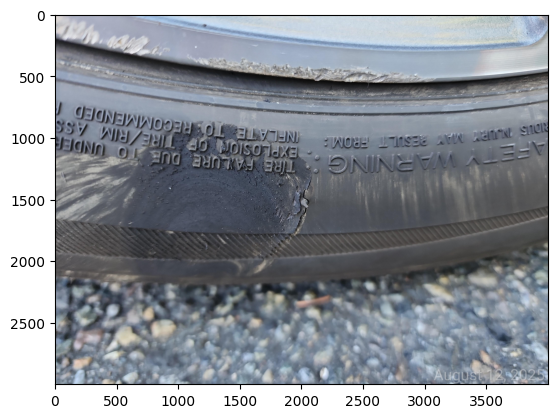

In [5]:
from ultralytics import YOLO
import cv2
from matplotlib import pyplot as plt

# 1. 모델 로드 (Pre-trained 모델 사용)
model = YOLO('yolov8n.pt') # 또는 직접 학습한 'best.pt'

# 2. 이미지 테스트 (동영상이나 웹캠 대신 일단 이미지 한 장으로 시작)
results = model('test_image.jpg')

# 3. 결과 시각화 (Bounding Box 확인)
res_plotted = results[0].plot()
plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
plt.show()

In [9]:
# 수정된 임포트 방식
from langchain_chroma import Chroma
from langchain_community.embeddings import DeterministicFakeEmbedding # 테스트용 가짜 임베딩
from langchain_text_splitters import CharacterTextSplitter

# 1. 설비 매뉴얼 데이터 (예시)
manual_text = """
설비 A의 표면에 스크래치가 발생하면 가동을 즉시 중단하십시오.
이후 세척액을 이용해 표면을 닦고 재검사하십시오.
"""

# 2. 텍스트 분할
text_splitter = CharacterTextSplitter(chunk_size=100, chunk_overlap=0)
texts = text_splitter.split_text(manual_text)

print(f"분할된 텍스트 개수: {len(texts)}")

c:\Users\human-31\project\ydataprofiling\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


분할된 텍스트 개수: 1


In [ ]:
import os
from torchvision import transforms
from PIL import Image
from torch.utils.data import Dataset, DataLoader

class MVTecDataset(Dataset):
    def __init__(self, root_path, category, transform=None, is_train=True):
        self.transform = transform
        self.mode = 'train' if is_train else 'test'
        self.data_path = os.path.join(root_path, category, self.mode)
        
        self.image_files = []
        for (root, dirs, files) in os.walk(self.data_path):
            for f in files:
                if f.endswith('.png'):
                    self.image_files.append(os.path.join(root, f))

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img = Image.open(self.image_files[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img

# 설정
data_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 사용 예시 (bottle 카테고리)
train_dataset = MVTecDataset(root_path='./mvtec_anomaly_detection', category='bottle', transform=data_transform, is_train=True)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"학습 이미지 개수: {len(train_dataset)}")

ValueError: num_samples should be a positive integer value, but got num_samples=0